# Publication Figures: RNA Polymerase Ribozyme Functional Design

This notebook generates publication-quality figures for the **RNA polymerase ribozyme (RPR) functional design validation** section of the gRNAde paper (Figure 3 and Figure 4).

1. **Success Rate Bar Chart** (`success_rate_of_active_designs.pdf`)
   - Success rates by edit distance and model (Figure 3D)

2. **Fitness Distribution Plots** (`fitness_distribution_boxplots.pdf`)
   - Stripplot + boxplot showing fitness by distance and model (Figure 3E)

3. **Stacked Bar Chart** (`designs_per_fitness_category.pdf`)
   - Library composition by fitness category (Active/Moderate/Inactive)

4. **Gel Correlation Plots** (`correlation_gel_vs_fitness_*.pdf`)
   - High-throughput fitness vs. low-throughput gel validation (Figure 3G)
   - Individual condition correlations

5. **Mutational Hotspot Analysis** (`mutation_probabilities_*.pdf`)
   - Per-position mutation frequencies for active designs (Figure 4A-C)
   - Comparison of gRNAde vs. rational design strategies

6. **Computational-Experimental Correlation** (`filtering_metrics_correlation.pdf`)
   - RibonanzaNet SHAPE scores vs. experimental fitness

## Input Data

- **`final_designs/all_designs_with_fitness_20032025.csv`**: Complete design library with experimental fitness (output from `calculate_fitness.ipynb`)
- **`final_designs/variants_gel_23102025.csv`**: Subset of designs validated in low-throughput gel assay

In [ ]:
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from tqdm.auto import tqdm

/home/ckj24/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define Reference Sequences

Define wild-type 5TU sequence and experimental flanking regions (same as in `calculate_fitness.ipynb`):
- **Wild-type 5TU**: 152 nt catalytic subunit
- **Total amplicon**: 192 bp with PCR primers

In [2]:
# Wildtype sequence for 5TU
wt_seq = "GGAUCUUCUCGAUCUAACAAAAAAGACAAAUCUGCCACAAAGCUUGAGAGCAUCUUCGGAUGCAGAGGCGGCAGCCUUCGGUGGCGCGAUAGCGCCAACGUUCUCAACUAUGACACGCAAAACGCGUGCUCCGUUGAAUGGAGUUUAUCAUG"
wt_seq = wt_seq.replace('U', 'T')
print(len(wt_seq))

# Flanking sequences for experiment
left_seq = 'AACAAACAACAAAACAAACAAACA'
right_seq = 'GGGTCGGCATGGCATC'
print(len(left_seq + wt_seq + right_seq))

wt_seq_with_flank = left_seq + wt_seq + right_seq

152
192


## Load and Prepare Design Data

Load the complete design library with experimental fitness values and prepare for visualization.

### Data Processing Steps:

1. **Load fitness data**: Read annotated designs from `calculate_fitness.ipynb` output
2. **Remove wild-type**: Exclude WT reference (fitness = 0 by definition) from analysis
3. **Categorize fitness**: Classify designs as Active/Moderately Active/Inactive
   - **Active**: fitness ≥ -1.86 (gel-validated threshold, variant 319)
   - **Moderately Active**: fitness < -1.86 but detectable in sequencing
   - **Inactive**: NaN fitness (not detected post-selection, <1 read)

4. **Format model names**: Convert to publication-ready labels
   - `gRNAde2` → `gRNAde pipeline`
   - `rational_heuristic` → `Rational design w/ filtering`
   - `rational_heuristic_random` → `Only rational design`

5. **Create edit distance bins**: Group designs into 5-mutation ranges for cleaner visualization
   - 15-19, 20-24, 25-29, 30-34, 35-39 mutations from wild-type

In [ ]:
# Load in the final designs with fitness data
df_designs = pd.read_csv('final_designs/all_designs_with_fitness_20032025.csv')
print("Number of sequences in designs with fitness_post_AUA_on_shortL_rc_trim_pfl data:", df_designs['fitness_post_AUA_on_shortL_rc_trim_pfl'].notna().sum())

# filter out the WT sequence as it always has a fitness of 0
df_designs = df_designs[df_designs['sequence_with_flanking'] != wt_seq_with_flank]

# Assign a new column called 'fitness_category' based on the fitness value in fitness_post_AUA_on_shortL_rc_trim_pfl
# - Above variant 319 (fitness = -1.86; shows detectable ligation activity in gel assay)
# - NaN - "inactive"
# - Everything else is "moderate"
def categorize_fitness(fitness_value):
    if pd.isna(fitness_value):
        return 'Inactive' 
    elif fitness_value >= -1.8627919725556008:
        return 'Active'
    else:
        return 'Moderately Active'
df_designs['fitness_category'] = df_designs['fitness_post_AUA_on_shortL_rc_trim_pfl'].apply(categorize_fitness)
# Print the counts of each fitness category
print(df_designs['fitness_category'].value_counts())

# Change model names to more readable format
def format_model_name(model_name):
    if model_name == 'gRNAde2':
        return 'gRNAde pipeline'
    elif model_name == 'rational_heuristic':
        return 'Rational design w/ filtering'
    elif model_name == 'rational_heuristic_random':
        return 'Only rational design'

# Create edit distance bins for cleaner visualization
df_designs['edit_dist_range'] = pd.cut(
    df_designs['edit_dist'], 
    bins=[14, 19, 24, 29, 34, 40], 
    labels=['15-19', '20-24', '25-29', '30-34', '35-39'],
    include_lowest=True
)
    
df_designs['model'] = df_designs['model'].apply(format_model_name)
print(df_designs['model'].unique())

df_designs

Number of sequences in designs with fitness_post_AUA_on_shortL_rc_trim_pfl data: 1199
fitness_category
Moderately Active    1088
Inactive              801
Active                110
Name: count, dtype: int64
['gRNAde pipeline' 'Rational design w/ filtering' 'Only rational design']


,fasta_desc,sequence,edit_dist,sc_score_ribonanzanet,sc_score_ribonanzanet_ss,model,seed,temperature,perplexity,sequence_with_flanking,fitness,fitness_post_GAA_3h_shortL_rc_trim_pfl,fitness_post_GAA_6h_shortL_rc_trim_pfl,fitness_post_AUA_on_shortL_rc_trim_pfl,fitness_post_GAA_3h_longL_rc_trim_pfl,fitness_post_GAA_6h_longL_rc_trim_pfl,fitness_post_AUA_on_longL_rc_trim_pfl,fitness_category,edit_dist_range
1,var5TU_gRNAde0001,GGATCTTCTCGATCTATTAAAAAAGACAAATCTGCCACAAAGCTTG...,15,0.081990,0.809393,gRNAde pipeline,3090,0.441924,1.235233,AACAAACAACAAAACAAACAAACAGGATCTTCTCGATCTATTAAAA...,-8.381630,NaN,NaN,NaN,-8.981745,-7.781515,NaN,Inactive,15-19
2,var5TU_gRNAde0002,GGATCTTCTCGATCTAATCAAAAAGACAAATCTGCCACAAAGCTTG...,15,0.083147,0.830978,gRNAde pipeline,6802,0.632620,1.212259,AACAAACAACAAAACAAACAAACAGGATCTTCTCGATCTAATCAAA...,-2.512221,-2.971837,-2.284227,-1.834079,-2.468793,-2.830984,-2.683405,Active,15-19
3,var5TU_gRNAde0003,GGATCTTCTCGATCTAACCAACAAGACAAATCTGCCACAAAGCTTG...,15,0.089538,0.830978,gRNAde pipeline,6802,0.632620,1.197458,AACAAACAACAAAACAAACAAACAGGATCTTCTCGATCTAACCAAC...,-2.394244,-2.523628,-2.340811,-1.868823,-2.726931,-2.883395,-2.021874,Moderately Active,15-19
4,var5TU_gRNAde0004,GGATCTTCTCGATCCACGAAACAAGACAAATCTGCCACAATGCTTG...,15,0.091939,0.917109,gRNAde pipeline,3809,0.743550,1.171488,AACAAACAACAAAACAAACAAACAGGATCTTCTCGATCCACGAAAC...,-0.235560,0.044039,0.170762,-0.798366,0.087741,-0.050255,-0.867283,Active,15-19
5,var5TU_gRNAde0005,GGATCTTCTCGATCTATTCTACAAGACAAATCTGCCAGAATGCTTG...,15,0.092202,0.872379,gRNAde pipeline,8374,0.327370,1.167326,AACAAACAACAAAACAAACAAACAGGATCTTCTCGATCTATTCTAC...,-5.699740,-3.622323,-2.284227,-8.657318,-4.747279,-3.595959,-11.291335,Moderately Active,15-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,var5TU_random0496,GGATATTCTCGATTCTAGCAATAAGACAAATCTGCCTCATGGCTTC...,39,0.242460,0.104234,Only rational design,4623,0.523349,0.000000,AACAAACAACAAAACAAACAAACAGGATATTCTCGATTCTAGCAAT...,-10.294976,-9.318794,NaN,NaN,NaN,NaN,-11.271157,Inactive,35-39
1996,var5TU_random0497,GGACCTTCTCGGTCTGGCACTTAAGACAAATCTGCCGTAAAGCTTT...,39,0.243123,0.377730,Only rational design,1824,0.624356,0.000000,AACAAACAACAAAACAAACAAACAGGACCTTCTCGGTCTGGCACTT...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inactive,35-39
1997,var5TU_random0498,GGATTTTCTCGATCTACCAATCAAGACAAATCTGTACAAACGCTTG...,39,0.203848,0.691423,Only rational design,492,1.169611,0.000000,AACAAACAACAAAACAAACAAACAGGATTTTCTCGATCTACCAATC...,-12.198251,NaN,-11.470094,-12.543817,NaN,NaN,-12.580842,Moderately Active,35-39
1998,var5TU_random0499,GGCTCTTCTCGAGCTAAGGATTAAGACAAATCTGCCAGAGAGCTTA...,39,0.203082,0.516794,Only rational design,3657,1.257757,0.000000,AACAAACAACAAAACAAACAAACAGGCTCTTCTCGAGCTAAGGATT...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Inactive,35-39


# Figure 3D: Success Rate of Active Designs

Generate bar chart showing percentage of active designs (fitness ≥ -1.86) by edit distance range and design method.

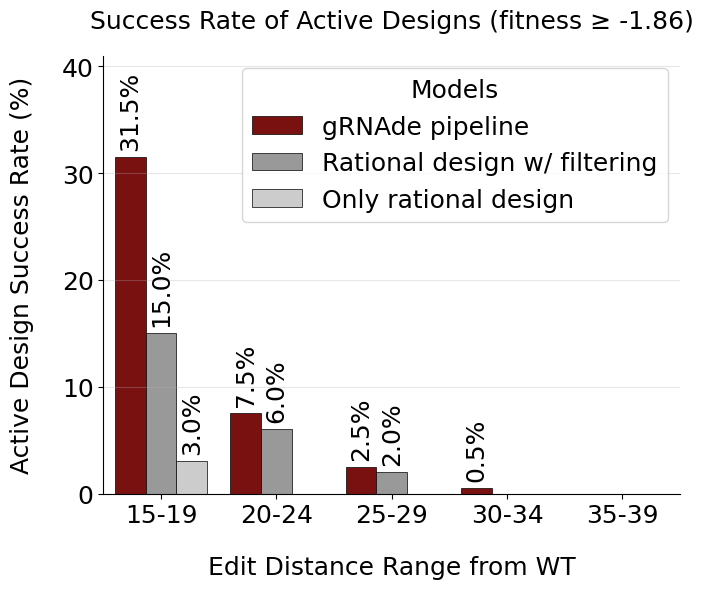

In [19]:
# ===== Success Rate Bar Chart =====

success_data = []

for model in df_designs['model'].unique():
    for dist_range in df_designs['edit_dist_range'].cat.categories:
        model_range_data = df_designs[(df_designs['model'] == model) & 
                                     (df_designs['edit_dist_range'] == dist_range)]
        
        if len(model_range_data) > 0:
            total_designs = len(model_range_data)
            # active_designs = len(model_range_data[model_range_data['fitness'] >= 0])
            active_designs = len(model_range_data[model_range_data['fitness_category'] == 'Active'])
            success_rate = (active_designs / total_designs) * 100
            
            success_data.append({
                'model': model,
                'distance_range': dist_range,
                'success_rate': success_rate,
                'total_designs': total_designs,
                'active_designs': active_designs
            })

success_df = pd.DataFrame(success_data)

# Define consistent colors for models - disability-friendly palette
model_colors = ['#8B0000', '#999999', '#CCCCCC']  # Dark red, medium grey, light grey
colors = {'gRNAde pipeline': '#8B0000', 'Rational design w/ filtering': '#999999', 'Only rational design': '#CCCCCC'}

# Prepare common data for legends
column_order = ['Active', 'Moderately Active', 'Inactive']
hatch_patterns = ['/////', '', 'xxx']  # Dense dots for Active, diagonal lines for Moderate, no pattern for Inactive
models = df_designs['model'].unique()

# Create legend elements
legend_elements = []
category_labels = {
    'Active': 'Active (fitness ≥ -1.86)', 
    'Moderately Active': 'Moderately Active', 
    'Inactive': 'Inactive (NaN fitness)'
}
legend_elements.append(Patch(facecolor='white', alpha=0, label='Fitness Categories:'))
for j, category in enumerate(column_order):
    legend_elements.append(Patch(facecolor='gray', alpha=0.8, hatch=hatch_patterns[j],
                                label=f'  {category_labels[category]}'))
legend_elements.append(Patch(facecolor='white', alpha=0, label=' '))
legend_elements.append(Patch(facecolor='white', alpha=0, label='Models:'))
for i, model in enumerate(models):
    legend_elements.append(Patch(facecolor=model_colors[i], alpha=0.8,
                                label=f'  {model}'))


fig1, ax1 = plt.subplots(figsize=(7, 6))

sns.barplot(
    data=success_df,
    x='distance_range',
    y='success_rate',
    hue='model',
    palette=model_colors,
    dodge=True,
    ax=ax1,
    edgecolor='black',
    linewidth=0.5
)

ax1.set_title('Success Rate of Active Designs (fitness ≥ -1.86)', fontsize=18, pad=20)
ax1.set_xlabel('Edit Distance Range from WT', fontsize=18, labelpad=20)
ax1.set_ylabel('Active Design Success Rate (%)', fontsize=18, labelpad=20)
ax1.tick_params(axis='both', which='major', labelsize=18)

ax1.legend(loc='upper right', frameon=True, title='Models', fontsize=18, title_fontsize=18)

# Add value labels on bars
for container in ax1.containers:
    # ax1.bar_label(container, fmt='%.1f%%', fontsize=12, rotation=0, padding=3)
    labels = []
    for bar in container:
        h = bar.get_height()
        labels.append(f'{h:.1f}%' if not np.isclose(h, 0) else '')
    ax1.bar_label(container, labels=labels, fontsize=18, rotation=90, padding=5)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.3, axis='y')

ax1.set_ylim(0, 41)

plt.tight_layout()
plt.savefig('figures/success_rate_of_active_designs.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3E: Fitness Distributions by Edit Distance

Generate stripplot with boxplot overlay showing fitness score distributions across edit distance ranges and design methods.

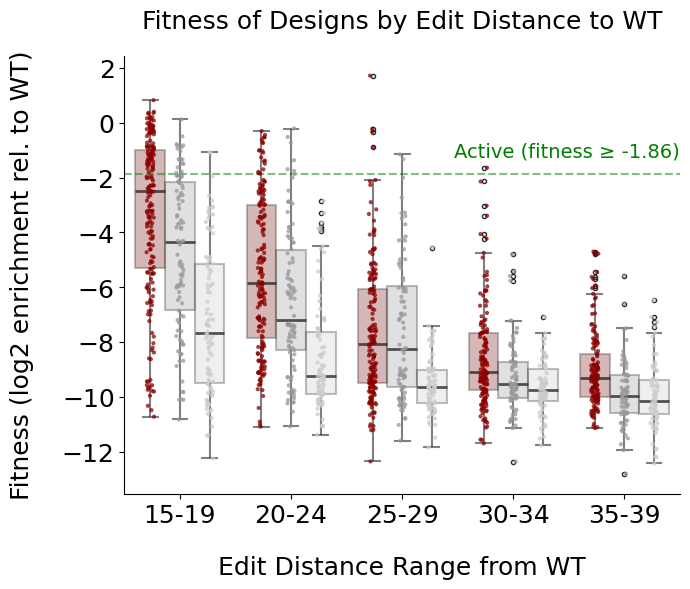

In [21]:
# ===== Fitness Distribution Stripplot with Boxplot =====

fig2, ax2 = plt.subplots(figsize=(7, 6))

sns.stripplot(
    data=df_designs,
    x='edit_dist_range',
    y='fitness',
    hue='model',
    palette=model_colors,
    dodge=True,
    alpha=0.75,
    size=3,
    edgecolor='w',
    linewidth=0.0,
    ax=ax2
)

# Add boxplot overlay
sns.boxplot(
    data=df_designs,
    x='edit_dist_range',
    y='fitness',
    hue='model',
    palette=model_colors,
    dodge=True,
    linewidth=1.5,
    fliersize=3,
    showfliers=True,
    boxprops=dict(alpha=0.3),
    medianprops=dict(alpha=0.8, linewidth=2),
    whiskerprops=dict(alpha=0.6),
    capprops=dict(alpha=0.6),
    ax=ax2
)

ax2.axhline(-1.86, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='Active threshold')
ax2.text(4.5, -1.86 + 0.50, 'Active (fitness ≥ -1.86)', fontsize=14, color='green', 
         ha='right', va='bottom')
ax2.set_title('Fitness of Designs by Edit Distance to WT', fontsize=18, pad=20)
ax2.set_xlabel('Edit Distance Range from WT', fontsize=18, labelpad=20)
ax2.set_ylabel('Fitness (log2 enrichment rel. to WT)', fontsize=18, labelpad=20)
ax2.tick_params(axis='both', which='major', labelsize=18)
ax2.legend().remove()

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/fitness_distribution_boxplots.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Library Composition by Fitness Category

Generate stacked bar chart showing absolute counts of designs in each fitness category (Active/Moderately Active/Inactive).

/tmp/ipykernel_1475219/2970934623.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fitness_counts = df_designs.groupby(['edit_dist_range', 'model', 'fitness_category']).size().unstack(fill_value=0)


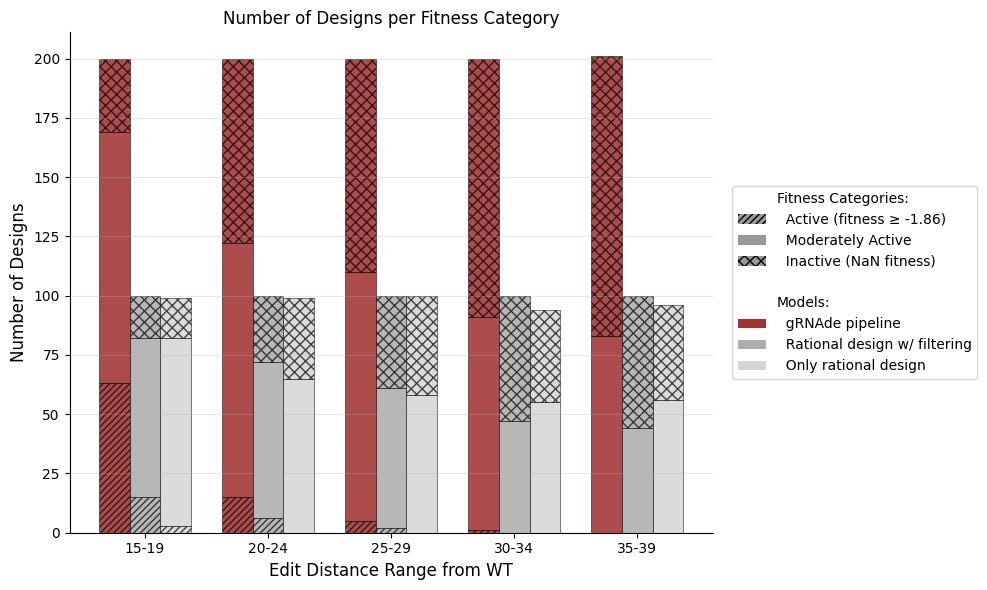

In [23]:
# ===== Stacked Bar Chart of Fitness Categories =====

# Make figure wider to accommodate legend while keeping axes width same as other figures
fig3, ax3 = plt.subplots(figsize=(10, 6))

# Create a pivot table to count sequences by fitness category, model, and distance bin
fitness_counts = df_designs.groupby(['edit_dist_range', 'model', 'fitness_category']).size().unstack(fill_value=0)
fitness_counts = fitness_counts.reindex(columns=column_order, fill_value=0)

distance_ranges = df_designs['edit_dist_range'].cat.categories
n_ranges = len(distance_ranges)
n_models = len(models)
bar_width = 0.25
x_positions = np.arange(n_ranges)

for i, model in enumerate(models):
    positions = x_positions + (i - 1) * bar_width
    bottom = np.zeros(n_ranges)
    
    for j, category in enumerate(column_order):
        values = []
        for dist_range in distance_ranges:
            try:
                count = fitness_counts.loc[(dist_range, model), category]
            except KeyError:
                count = 0
            values.append(count)
        
        values = np.array(values)
        ax3.bar(positions, values, bar_width, bottom=bottom, 
               color=model_colors[i], alpha=0.7, hatch=hatch_patterns[j],
               edgecolor='black', linewidth=0.5)
        bottom += values

ax3.set_xlabel('Edit Distance Range from WT', fontsize=12)
ax3.set_ylabel('Number of Designs', fontsize=12)
ax3.set_title('Number of Designs per Fitness Category', fontsize=12, loc='center')
ax3.set_xticks(x_positions)
ax3.set_xticklabels(distance_ranges)
ax3.grid(True, alpha=0.3, axis='y')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Add legend only to the last figure
ax3.legend(handles=legend_elements, bbox_to_anchor=(1.02, 0.5), loc='center left', frameon=True)

plt.tight_layout()
plt.savefig('figures/designs_per_fitness_category.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3F-G: Gel Validation and Correlation Analysis

Generate correlation plots between high-throughput sequencing fitness and low-throughput gel-based activity measurements.

**Gel assay details:**
- **9 gRNAde variants** selected across edit distance ranges (15-19, 20-24, 25-29)
- **Template**: 14 repeats of CGU triplet
- **Measurement**: Average per-junction ligation efficiency (0-1 scale, quantification from gel)
- **Wild-type control**: WT 5TU for normalization

/tmp/ipykernel_1475219/408054659.py:43: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if col in df_designs_subset.columns and pd.api.types.is_categorical_dtype(df_designs_subset[col]):


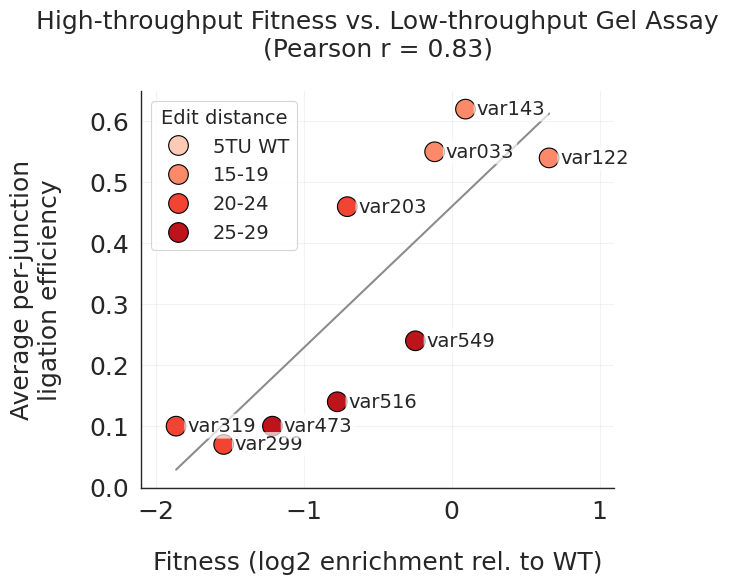

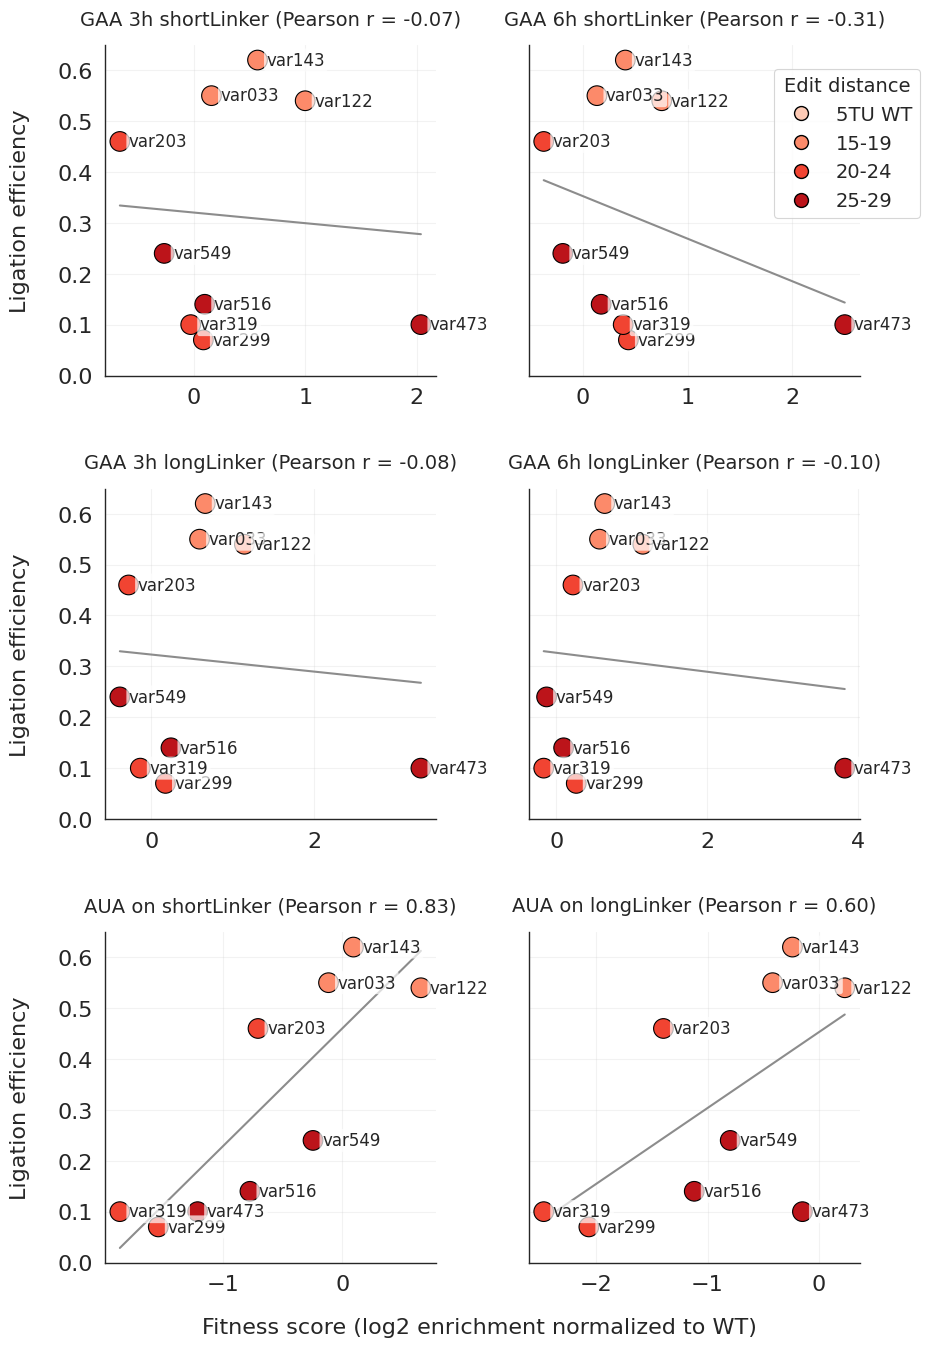

In [41]:
# Correlation plots for high-throughput fitness vs low-throughput gel assay

# IDs of a subset of variants that were tested experimentally via gel assay on 4/11/2025
subset_fasta_desc = pd.read_csv("final_designs/variants_gel_23102025.csv")["fasta_desc"]

# Filter the designs dataframe to only include these variants
df_designs_subset = df_designs[df_designs['fasta_desc'].isin(subset_fasta_desc)].copy()
# Add WT row
df_designs_subset = pd.concat([df_designs_subset, df_designs[df_designs['fasta_desc'] == "5TU"]])

# Experimental number of gel bands for the subset of variants tested
gel_bands = {
    "5TU": 11,
    "var5TU_gRNAde0122": 13,
    "var5TU_gRNAde0143": 14,
    "var5TU_gRNAde0033": 11,
    "var5TU_gRNAde0299": 3,
    "var5TU_gRNAde0203": 8,
    "var5TU_gRNAde0319": 3,
    "var5TU_gRNAde0473": 4,
    "var5TU_gRNAde0516": 4,
    "var5TU_gRNAde0549": 5
}
df_designs_subset['gel_bands'] = df_designs_subset['fasta_desc'].map(gel_bands)

# Experimental quantified values: the average per-junction ligation efficiency, which summarises each reaction in one number
ligation_efficiency = {
    "5TU": 0.52,
    "var5TU_gRNAde0122": 0.54,
    "var5TU_gRNAde0143": 0.62,
    "var5TU_gRNAde0033": 0.55,
    "var5TU_gRNAde0299": 0.07,
    "var5TU_gRNAde0203": 0.46,
    "var5TU_gRNAde0319": 0.10,
    "var5TU_gRNAde0473": 0.10,
    "var5TU_gRNAde0516": 0.14,
    "var5TU_gRNAde0549": 0.24
}
df_designs_subset['ligation_efficiency'] = df_designs_subset['fasta_desc'].map(ligation_efficiency)

# Minor adjustments for plotting
mask = df_designs_subset['fasta_desc'] == '5TU'
df_designs_subset.loc[mask, 'model'] = '5TU WT'
col = 'edit_dist_range'
if col in df_designs_subset.columns and pd.api.types.is_categorical_dtype(df_designs_subset[col]):
    # add the new category if necessary before assignment
    if '5TU WT' not in df_designs_subset[col].cat.categories:
        df_designs_subset[col] = df_designs_subset[col].cat.add_categories(['5TU WT'])
df_designs_subset.loc[mask, col] = '5TU WT'
df_designs_subset["variant"] = df_designs_subset["fasta_desc"].apply(lambda x: x[-3:])

###

# Correlation plot with post libary with best correlation: fitness_post_AUA_on_shortL_rc_trim_pfl	

from matplotlib.lines import Line2D

sns.set_style("white")
sns.set_context("paper", font_scale=1.2)

hue_col = "edit_dist_bin" if "edit_dist_bin" in df_designs_subset.columns else "edit_dist_range"

post_lib = 'post_AUA_on_shortL_rc_trim_pfl'
col_name = f"fitness_{post_lib}"

fig, ax = plt.subplots(1, 1, figsize=(6.5, 6))

if df_designs_subset[hue_col].dtype.name == "category":
    categories = [c for c in df_designs_subset[hue_col].cat.categories if c in df_designs_subset[hue_col].dropna().unique()]
else:
    categories = sorted(df_designs_subset[hue_col].dropna().unique(), key=lambda x: str(x))
categories = ['5TU WT', '15-19', '20-24', '25-29',]  # manual ordering
palette_list = sns.color_palette("Reds", n_colors=max(1, len(categories)))
palette_map = dict(zip(categories, palette_list))

# include variant column so we can annotate points
data = df_designs_subset[[col_name, "ligation_efficiency", hue_col, "variant"]].dropna()

sns.scatterplot(x=col_name, y="ligation_efficiency", data=data,
                hue=hue_col, hue_order=categories, palette=palette_map,
                s=200, edgecolor="k", linewidth=0.8, ax=ax, zorder=2, legend=True)

# annotate each point with the 3-character variant code
x_range = data[col_name].max() - data[col_name].min()
x_offset = x_range * 0.03 if x_range != 0 else 0.03
for _, r in data.iterrows():
    if str(r["variant"]) == "5TU":
        annotation = "5TU"
    else:
        annotation = "var" + str(r["variant"])
    ax.text(r[col_name] + x_offset, r["ligation_efficiency"], annotation,
            fontsize=14, ha="left", va="center", zorder=4,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.7, ec="none"))

m, b = np.polyfit(data[col_name], data["ligation_efficiency"], 1)
xs = np.linspace(data[col_name].min(), data[col_name].max(), 200)
ax.plot(xs, m * xs + b, color="gray", linewidth=1.5, zorder=1, alpha=0.9)

r = data[col_name].corr(data["ligation_efficiency"])
title = f"High-throughput Fitness vs. Low-throughput Gel Assay\n(Pearson r = {r:.2f})"
    
ax.set_title(title, fontsize=18, pad=25)
ax.set_xlabel("Fitness (log2 enrichment rel. to WT)", fontsize=18, labelpad=20)
ax.set_ylabel("Average per-junction\nligation efficiency", fontsize=18, labelpad=20)
ax.grid(alpha=0.25)
ax.tick_params(axis='both', which='major', labelsize=18)

sns.despine(ax=ax)

ax.set_xlim(-2.1, 1.1)

ax.legend(title="Edit distance", loc='upper left', frameon=True, fontsize=14, title_fontsize=14)

plt.tight_layout()
plt.savefig('figures/correlation_gel_vs_fitness_post_AUA_on_shortL.pdf', dpi=300, bbox_inches='tight')
plt.show()


###

# Correlation plots for all post libraries

hue_col = "edit_dist_bin" if "edit_dist_bin" in df_designs_subset.columns else "edit_dist_range"

posts = [
    'post_GAA_3h_shortL_rc_trim_pfl',
    'post_GAA_6h_shortL_rc_trim_pfl',
    'post_GAA_3h_longL_rc_trim_pfl',
    'post_GAA_6h_longL_rc_trim_pfl',
    'post_AUA_on_shortL_rc_trim_pfl',
    'post_AUA_on_longL_rc_trim_pfl'
]
fig, axes = plt.subplots(3, 2, figsize=(10, 14), sharey=True)
axes = axes.flatten()

if df_designs_subset[hue_col].dtype.name == "category":
    categories = [c for c in df_designs_subset[hue_col].cat.categories if c in df_designs_subset[hue_col].dropna().unique()]
else:
    categories = sorted(df_designs_subset[hue_col].dropna().unique(), key=lambda x: str(x))
categories = ['5TU WT', '15-19', '20-24', '25-29',]  # manual ordering
palette_list = sns.color_palette("Reds", n_colors=max(1, len(categories)))
palette_map = dict(zip(categories, palette_list))

for i, post_lib in enumerate(posts):
    ax = axes[i]
    col_name = f"fitness_{post_lib}"
    if col_name not in df_designs_subset.columns:
        ax.set_visible(False)
        continue

    # include variant column so we can annotate points
    data = df_designs_subset[[col_name, "ligation_efficiency", hue_col, "variant"]].dropna()
    if data.shape[0] == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(post_lib.replace("_", " "))
        continue

    sns.scatterplot(x=col_name, y="ligation_efficiency", data=data,
                    hue=hue_col, hue_order=categories, palette=palette_map,
                    s=200, edgecolor="k", linewidth=0.8, ax=ax, zorder=2, legend=False)

    # annotate each point with the 3-character variant code
    x_range = data[col_name].max() - data[col_name].min()
    x_offset = x_range * 0.03 if x_range != 0 else 0.03
    for _, r in data.iterrows():
        if str(r["variant"]) == "5TU":
            annotation = "5TU"
        else:
            annotation = "var" + str(r["variant"])
        ax.text(r[col_name] + x_offset, r["ligation_efficiency"], annotation,
                fontsize=12, ha="left", va="center", zorder=4,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.7, ec="none"))

    m, b = np.polyfit(data[col_name], data["ligation_efficiency"], 1)
    xs = np.linspace(data[col_name].min(), data[col_name].max(), 200)
    ax.plot(xs, m * xs + b, color="gray", linewidth=1.5, zorder=1, alpha=0.9)

    r = data[col_name].corr(data["ligation_efficiency"])
    
    title = f'{post_lib.split("_")[1]} {post_lib.split("_")[2]} {post_lib.split("_")[3]}inker (Pearson r = {r:.2f})'

    ax.set_title(title, fontsize=14, pad=15)
    ax.set_xlabel("")
    ax.set_ylabel("Ligation efficiency" if i % 2 == 0 else "", fontsize=16, labelpad=20)
    ax.grid(alpha=0.25)
    ax.tick_params(axis='both', which='major', labelsize=16)
    sns.despine(ax=ax)

for j in range(len(posts), len(axes)):
    axes[j].set_visible(False)

if len(categories) > 0:
    handles = [Line2D([0], [0], marker='o', color='w',
                      markerfacecolor=palette_map[c], markeredgecolor='k',
                      markersize=10, linewidth=0.8) for c in categories]
    fig.legend(handles, categories, title="Edit distance", loc='upper right', bbox_to_anchor=(0.95, 0.92), fontsize=14, title_fontsize=14, frameon=True)

fig.text(0.5, 0.01, "Fitness score (log2 enrichment normalized to WT)", ha="center", fontsize=16)
plt.subplots_adjust(hspace=0.34, wspace=0.28, top=0.93, bottom=0.06, right=0.88)
plt.savefig('figures/correlation_gel_vs_fitness_all.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4A-C: Mechanistic Analysis - Mutational Hotspots

Analyze per-position mutation frequencies in active designs to understand design strategies.

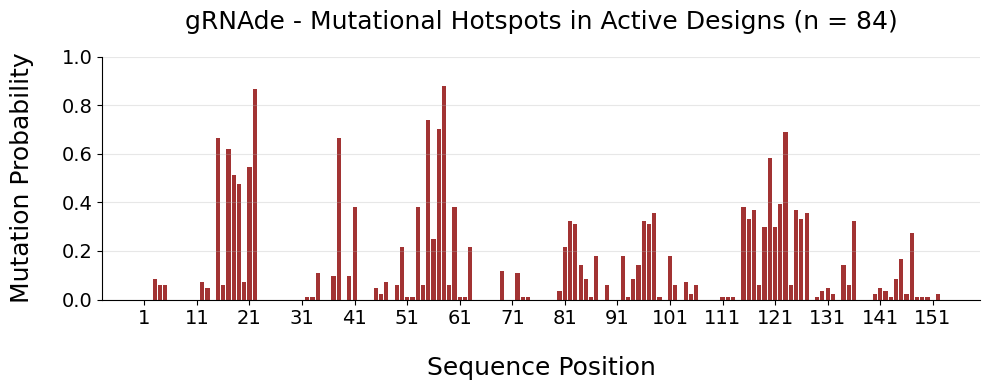

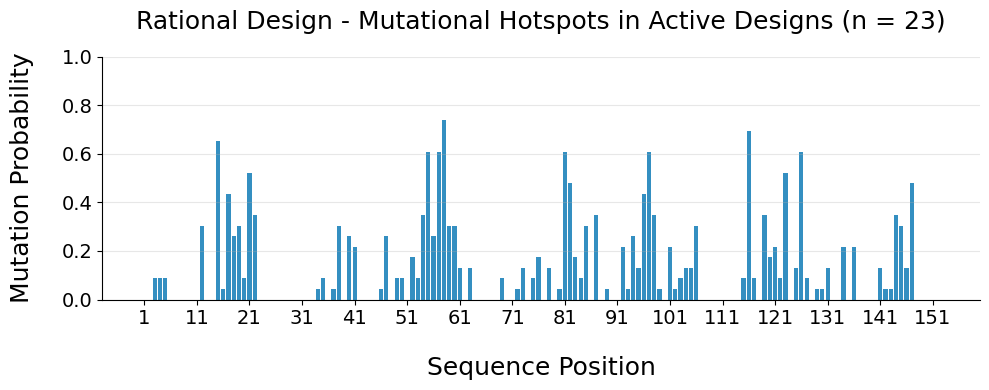

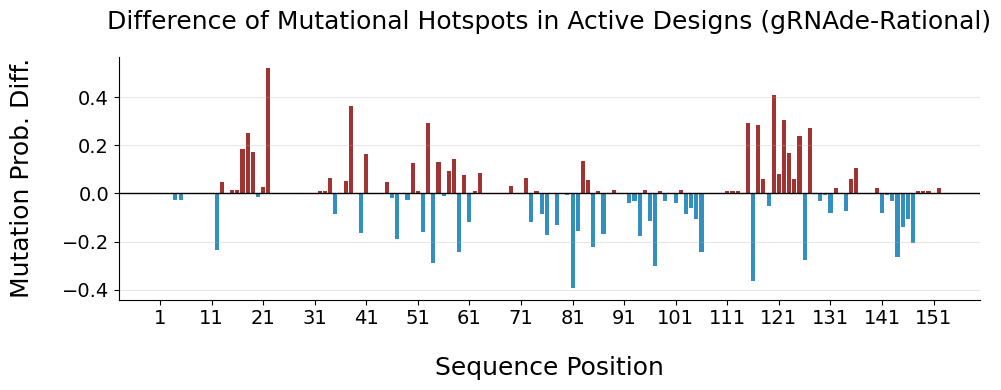

In [33]:
# ===== Mutation Probability Plots for Active Designs =====

# Filter out all active designs for gRNAde and rational + filtering
active_designs = df_designs[(df_designs['fitness_category'] == 'Active') & (df_designs['model'].isin(['gRNAde pipeline', 'Rational design w/ filtering']))]

# For both the models, calculate the probability of each position in the WT sequence being mutated/different from the WT sequence
def calculate_mutation_probabilities(df, wt_seq):
    """Calculate mutation probabilities for each position in the WT sequence."""
    mutation_probs = np.zeros(len(wt_seq))
    
    for seq in df['sequence']:
        for i, (wt_base, mut_base) in enumerate(zip(wt_seq, seq.replace('T', 'U'))):
            if wt_base != mut_base:
                mutation_probs[i] += 1
    
    # Normalize by the number of designs
    mutation_probs /= len(df)
    
    return mutation_probs

# Calculate mutation probabilities for gRNAde and rational designs
grnade_mutation_probs = calculate_mutation_probabilities(active_designs[active_designs['model'] == 'gRNAde pipeline'], wt_seq.replace('T', 'U'))
rational_mutation_probs = calculate_mutation_probabilities(active_designs[active_designs['model'] == 'Rational design w/ filtering'], wt_seq.replace('T', 'U'))

fig1, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(np.arange(len(wt_seq)), grnade_mutation_probs, 
    color='#8B0000', alpha=0.8, width=0.8)
ax1.set_title(f"gRNAde - Mutational Hotspots in Active Designs (n = {len(active_designs[active_designs['model'] == 'gRNAde pipeline'])})", fontsize=18, pad=20)
ax1.set_ylabel("Mutation Probability", fontsize=18, labelpad=20)
ax1.set_xlabel("Sequence Position", fontsize=18, labelpad=20)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3, axis='y')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xticks(np.arange(len(wt_seq))[::10])
ax1.set_xticklabels([f"{i}" for i in range(1, len(wt_seq) + 1, 10)], fontsize=12)
ax1.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.savefig("figures/mutation_probabilities_active_grnade.pdf", dpi=300, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.bar(np.arange(len(wt_seq)), rational_mutation_probs, 
    color='#0173B2', alpha=0.8, width=0.8)
ax2.set_title(f"Rational Design - Mutational Hotspots in Active Designs (n = {len(active_designs[active_designs['model'] == 'Rational design w/ filtering'])})", fontsize=18, pad=20)
ax2.set_ylabel("Mutation Probability", fontsize=18, labelpad=20)
ax2.set_xlabel("Sequence Position", fontsize=18, labelpad=20)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3, axis='y')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticks(np.arange(len(wt_seq))[::10])
ax2.set_xticklabels([f"{i}" for i in range(1, len(wt_seq) + 1, 10)], fontsize=8)
ax2.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.savefig("figures/mutation_probabilities_active_rational.pdf", dpi=300, bbox_inches='tight')
plt.show()

fig3, ax3 = plt.subplots(figsize=(10, 4))
diff = grnade_mutation_probs - rational_mutation_probs
colors = ['#8B0000' if x > 0 else '#0173B2' for x in diff]
ax3.bar(np.arange(len(wt_seq)), diff, 
    color=colors, alpha=0.8, width=0.8)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_title("Difference of Mutational Hotspots in Active Designs (gRNAde-Rational)", fontsize=18, pad=20)
ax3.set_xlabel("Sequence Position", fontsize=18, labelpad=20)
ax3.set_ylabel("Mutation Prob. Diff.", fontsize=18, labelpad=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_xticks(np.arange(len(wt_seq))[::10])
ax3.set_xticklabels([f"{i}" for i in range(1, len(wt_seq) + 1, 10)], fontsize=14)
ax3.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.savefig("figures/mutation_probabilities_active_difference.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Supplementary Analysis: Computational Screening vs. Experimental Fitness

Analyze correlation between RibonanzaNet computational scores (used for pre-selection filtering) and experimental fitness outcomes.

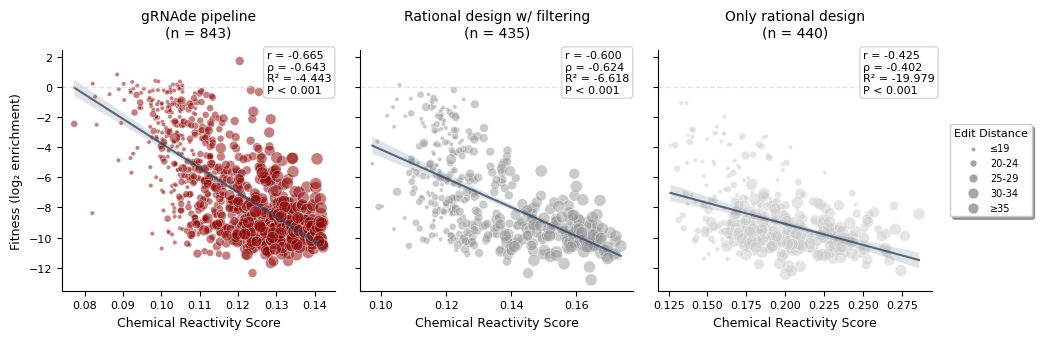

Correlation Analysis Summary:
                       Model   N      R²  RMSE   MAE  Pearson r  Pearson p  Spearman ρ  Spearman p
             gRNAde pipeline 843  -4.443 7.505 6.785     -0.665        0.0      -0.643         0.0
Rational design w/ filtering 435  -6.618 8.095 7.541     -0.600        0.0      -0.624         0.0
        Only rational design 440 -19.979 9.317 9.090     -0.425        0.0      -0.402         0.0



In [34]:
# ==== Correlation plots for chemical reactivity score vs fitness =====

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr

metric = 'sc_score_ribonanzanet'

# Create a figure with subplots for each model
models = df_designs['model'].unique()
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(3.5*n_models, 3.5), sharex=False, sharey=True)
if n_models == 1:
    axes = [axes]

# Store correlation metrics for summary
correlation_summary = []

# Define Nature-style colors
colors = ['#8B0000', '#999999', "#CCCCCC"]
point_alpha = 0.5

# Define size mapping for legend
size_mapping = {
    '≤19': 10,
    '20-24': 25,
    '25-29': 40,
    '30-34': 60,
    '≥35': 60
}

for i, model in enumerate(models):
    model_df = df_designs[df_designs["model"] == model]

    # Filter out NaN values for the metric
    model_df = model_df.dropna(subset=['fitness', metric])
    if len(model_df) <= 1:
        continue
    
    # Calculate correlation metrics
    rmse = np.sqrt(mean_squared_error(model_df['fitness'], model_df[metric]))
    mae = mean_absolute_error(model_df['fitness'], model_df[metric])
    r2 = r2_score(model_df['fitness'], model_df[metric])
    pearson_corr, pearson_p = pearsonr(model_df['fitness'], model_df[metric])
    spearman_corr, spearman_p = spearmanr(model_df['fitness'], model_df[metric])
    
    correlation_summary.append({
        'Model': model,
        'N': len(model_df),
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae,
        'Pearson r': pearson_corr,
        'Pearson p': pearson_p,
        'Spearman ρ': spearman_corr,
        'Spearman p': spearman_p
    })
    
    # Create scatter plot with regression line
    # Make marker size proportional to edit distance
    marker_sizes = []
    for edit_dist in model_df['edit_dist']:
        if edit_dist <= 19:
            size = 10  # Smallest for closest distances
        elif edit_dist <= 24:
            size = 25
        elif edit_dist <= 29:
            size = 40
        elif edit_dist <= 34:
            size = 60
        else:
            size = 75  # Largest for furthest distances
        marker_sizes.append(size)
    
    # Scatter plot with better styling
    axes[i].scatter(
        model_df[metric],
        model_df['fitness'],
        alpha=point_alpha,
        s=marker_sizes,
        color=colors[i % len(colors)],
        edgecolors='white',
        linewidths=0.5
    )
    
    # Add regression line with confidence interval
    sns.regplot(
        data=model_df,
        x=metric,
        y='fitness',
        scatter=False,
        ax=axes[i],
        color='#34495E',  # Dark gray
        line_kws={'linewidth': 1.5, 'alpha': 0.8}
    )
    
    # Customize plot with Nature style
    axes[i].set_title(f'{model}\n(n = {len(model_df)})', fontsize=10, pad=10)
    axes[i].set_xlabel('Chemical Reactivity Score', fontsize=9)
    if i == 0:  # Only label y-axis for leftmost plot
        axes[i].set_ylabel('Fitness (log₂ enrichment)', fontsize=9)
    else:
        axes[i].set_ylabel('')
    
    # Add correlation statistics as text with better formatting
    if pearson_p < 0.001:
        p_text = 'P < 0.001'
    elif pearson_p < 0.01:
        p_text = f'P < 0.01'
    elif pearson_p < 0.05:
        p_text = f'P < 0.05'
    else:
        p_text = f'P = {pearson_p:.3f}'
    
    stats_text = f'r = {pearson_corr:.3f}\nρ = {spearman_corr:.3f}\nR² = {r2:.3f}\n{p_text}'
    axes[i].text(0.75, 1.0, stats_text, 
                transform=axes[i].transAxes,
                fontsize=8,
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='lightgray'))
    
    # Add horizontal line at fitness=0
    axes[i].axhline(y=0, color='lightgray', linestyle='--', alpha=0.6, linewidth=1)
    
    # Improve tick formatting
    axes[i].tick_params(axis='both', which='major', labelsize=8)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_linewidth(0.8)
    axes[i].spines['bottom'].set_linewidth(0.8)

# Create size legend (only add to the rightmost subplot)
legend_elements = []
for label, size in size_mapping.items():
    legend_elements.append(plt.scatter([], [], s=size, c='gray', alpha=0.7, 
                                     edgecolors='white', linewidths=0.5, label=label))

# Add legend to the rightmost subplot - positioned outside the plot area
axes[-1].legend(handles=legend_elements, title='Edit Distance', 
               bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize=7, title_fontsize=8,
               frameon=True, fancybox=True, shadow=True)

plt.tight_layout()

plt.savefig('figures/filtering_metrics_correlation.pdf', dpi=300, bbox_inches='tight')

plt.show()

# Create summary table
correlation_df = pd.DataFrame(correlation_summary)
print("Correlation Analysis Summary:")
print("=" * 50)
print(correlation_df.round(3).to_string(index=False))
print()
